In [44]:
import pandas as pd
import numpy as np

In [45]:
# Ler o arquivo CSV
df = pd.read_csv('fifa21_limpo.csv')


In [46]:
# Informações básicas
print("Shape:", df.shape)
print("\nColunas:")
print(df.columns.tolist())
print("\nPrimeiras linhas:")
df.head(3)

Shape: (18978, 80)

Colunas:
['photoUrl', 'LongName', 'playerUrl', 'Nationality', 'Positions', 'Name', 'Age', '↓OVA', 'POT', 'Team & Contract', 'ID', 'Height', 'Weight', 'foot', 'BOV', 'BP', 'Growth', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits', 'Height(cm)', 'Weight(kg)', 'BMI']

Primeiras linhas:


,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Height(cm),Weight(kg),BMI
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,85,92,91,95,38,65,372.0,170.2,72.1,24.889499
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,89,93,81,89,35,77,344.0,188.0,83.0,23.483477
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,87,92,78,90,52,90,86.0,188.0,87.1,24.643504


In [47]:
#Preparar os dados
#Renomear coluna OVA
df = df.rename(columns={'↓OVA': 'OVA'})

In [48]:
# Extrair time principal da coluna 'Team & Contract'
df['Team'] = df['Team & Contract'].str.extract(r'\n\n\n\n([^\n]+)')


In [49]:
# Limpar valores monetários (converter para milhões)
def clean_money(val):
    if pd.isna(val) or val == 0:
        return 0
    val = str(val).replace(',', '')
    if 'M' in val:
        return float(val.replace('M', ''))
    elif 'K' in val:
        return float(val.replace('K', '')) / 1000
    else:
        try:
            return float(val) / 1000000
        except:
            return 0

In [50]:
# As colunas já estão em formato numérico, vamos verificar
df['Value_M'] = df['Value'] / 1000000
df['Wage_K'] = df['Wage'] / 1000
df['Release_Clause_M'] = df['Release Clause'] / 1000000

# Extrair posição principal
df['Main_Position'] = df['Positions'].str.split().str[0]

In [51]:
# Categorias de posição
def categorize_position(pos):
    if pd.isna(pos):
        return 'Unknown'
    pos = str(pos)
    if pos in ['GK']:
        return 'Goleiro'
    elif pos in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defensor'
    elif pos in ['CDM', 'CM', 'CAM', 'LM', 'RM']:
        return 'Meio-campo'
    elif pos in ['LW', 'RW', 'LF', 'RF', 'ST', 'CF']:
        return 'Atacante'
    else:
        return 'Outro'

df['Position_Category'] = df['Main_Position'].apply(categorize_position)

# Identificar ligas
leagues = {
    'Premier League': ['Manchester City', 'Liverpool', 'Chelsea', 'Manchester United', 'Tottenham Hotspur', 'Arsenal', 'Leicester City', 'Everton', 'West Ham United', 'Wolverhampton Wanderers', 'Burnley', 'Newcastle United', 'Crystal Palace'],
    'La Liga': ['Real Madrid', 'FC Barcelona', 'Atlético Madrid', 'Sevilla FC', 'Villarreal CF', 'Real Sociedad', 'Valencia CF', 'Athletic Club de Bilbao', 'Real Betis', 'Getafe CF', 'Levante UD', 'Deportivo Alavés', 'RC Celta', 'Real Valladolid CF'],
    'Serie A': ['Juventus', 'Inter', 'Milan', 'Napoli', 'Roma', 'Lazio', 'Atalanta', 'Fiorentina', 'Torino', 'Sassuolo', 'Cagliari'],
    'Bundesliga': ['FC Bayern München', 'Borussia Dortmund', 'RB Leipzig', 'Borussia Mönchengladbach', 'Bayer 04 Leverkusen', 'Eintracht Frankfurt', 'VfL Wolfsburg', 'TSG 1899 Hoffenheim', 'SV Werder Bremen', '1. FC Union Berlin'],
    'Ligue 1': ['Paris Saint-Germain', 'Olympique Lyonnais', 'AS Monaco', 'LOSC Lille', 'Olympique de Marseille', 'OGC Nice']
}

def get_league(team):
    for league, teams in leagues.items():
        if team in teams:
            return league
    return 'Outras'

df['League'] = df['Team'].apply(get_league)

print(f"Dados carregados: {len(df)} jogadores, {df['Team'].nunique()} times")
print("Pronto para recriar os dashboards!")

Dados carregados: 18978 jogadores, 681 times
Pronto para recriar os dashboards!


In [52]:
# Verificar dados limpos
print("Times únicos:", df['Team'].nunique())
print("Posições principais:", df['Main_Position'].unique()[:15])
print("Categorias de posição:", df['Position_Category'].value_counts())
print("\nEstatísticas de Valor (em milhões):")
print(df['Value_M'].describe())

Times únicos: 681
Posições principais: ['RW' 'ST' 'GK' 'CAM' 'LW' 'CB' 'CDM' 'CF' 'CM' 'RM' 'RB' 'LB' 'LM' 'RWB'
 'LWB']
Categorias de posição: Position_Category
Meio-campo    7029
Defensor      6246
Atacante      3628
Goleiro       2075
Name: count, dtype: int64

Estatísticas de Valor (em milhões):
count    18978.000000
mean         2.229071
std          5.097723
min          0.000000
25%          0.300000
50%          0.650000
75%          1.800000
max        105.500000
Name: Value_M, dtype: float64


In [53]:
#Criar visualizações
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'

# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')



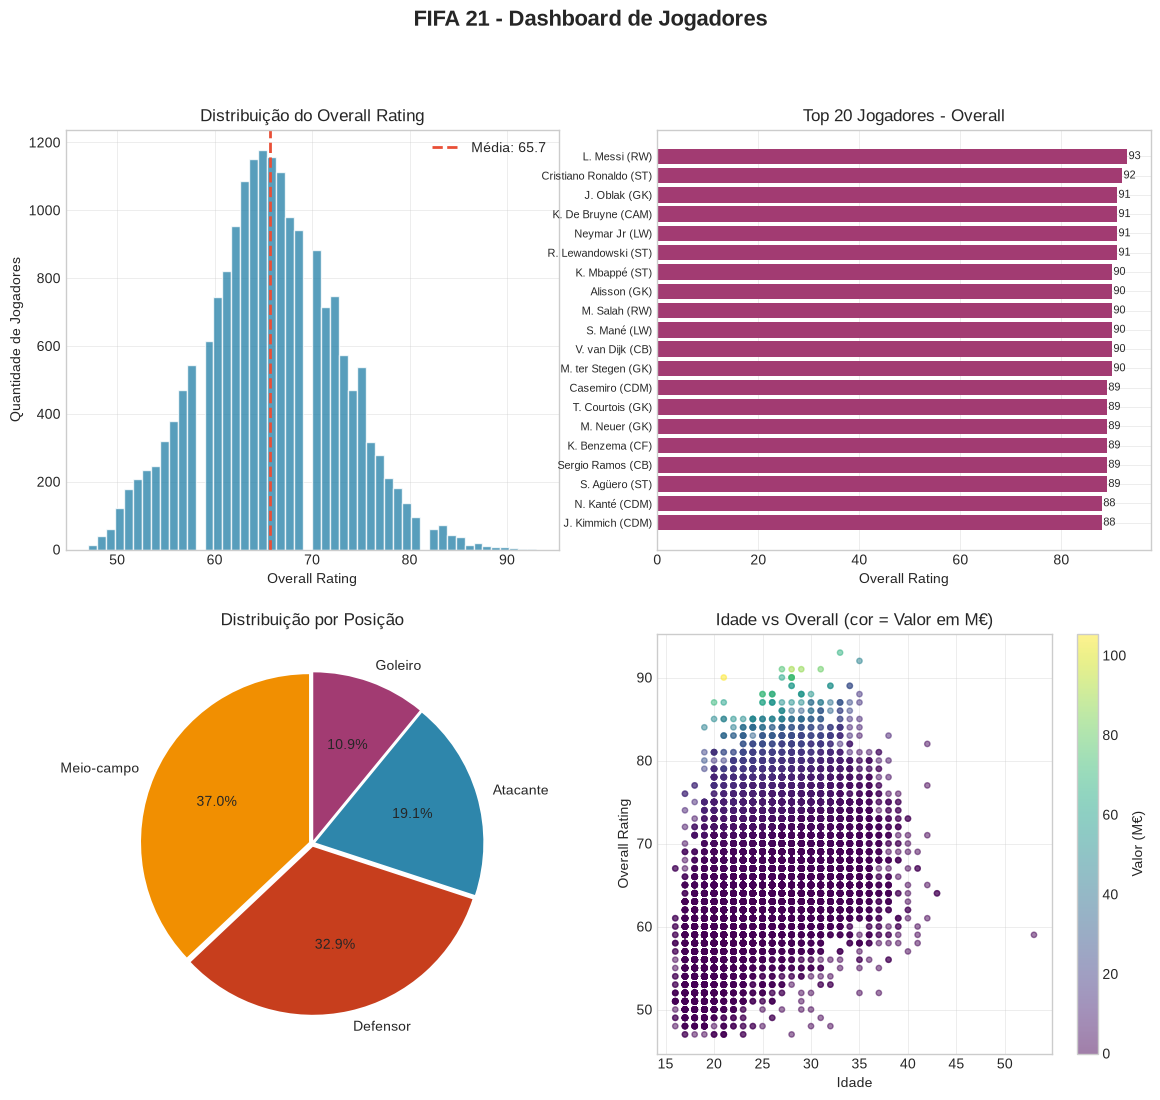

In [54]:
# Figura 1: Distribuição de Overall Rating
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('FIFA 21 - Dashboard de Jogadores', fontsize=16, fontweight='bold')

# 1. Distribuição de Overall Rating
ax1 = axes[0, 0]
ax1.hist(df['OVA'], bins=50, color='#2E86AB', edgecolor='white', alpha=0.8)
ax1.axvline(df['OVA'].mean(), color='#E94F37', linestyle='--', linewidth=2, label=f'Média: {df["OVA"].mean():.1f}')
ax1.set_xlabel('Overall Rating')
ax1.set_ylabel('Quantidade de Jogadores')
ax1.set_title('Distribuição do Overall Rating')
ax1.legend()

# 2. Top 20 jogadores por Overall
ax2 = axes[0, 1]
top20 = df.nlargest(20, 'OVA')[['Name', 'OVA', 'Team', 'Main_Position']]
bars = ax2.barh(range(len(top20)), top20['OVA'].values, color='#A23B72')
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels([f"{n} ({p})" for n, p in zip(top20['Name'].values, top20['Main_Position'].values)], fontsize=8)
ax2.set_xlabel('Overall Rating')
ax2.set_title('Top 20 Jogadores - Overall')
ax2.invert_yaxis()
for i, (v, t) in enumerate(zip(top20['OVA'].values, top20['Team'].values)):
    ax2.text(v + 0.3, i, f'{v}', va='center', fontsize=8)

# 3. Distribuição por categoria de posição
ax3 = axes[1, 0]
pos_counts = df['Position_Category'].value_counts()
colors = ['#F18F01', '#C73E1D', '#2E86AB', '#A23B72']
wedges, texts, autotexts = ax3.pie(pos_counts.values, labels=pos_counts.index, autopct='%1.1f%%',
                                    colors=colors, startangle=90, explode=(0.02, 0.02, 0.02, 0.02))
ax3.set_title('Distribuição por Posição')

# 4. Relação Idade vs Overall
ax4 = axes[1, 1]
scatter = ax4.scatter(df['Age'], df['OVA'], c=df['Value_M'], cmap='viridis', alpha=0.5, s=15)
ax4.set_xlabel('Idade')
ax4.set_ylabel('Overall Rating')
ax4.set_title('Idade vs Overall (cor = Valor em M€)')
plt.colorbar(scatter, ax=ax4, label='Valor (M€)')


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/agents/output/fifa21_dashboard2.png'

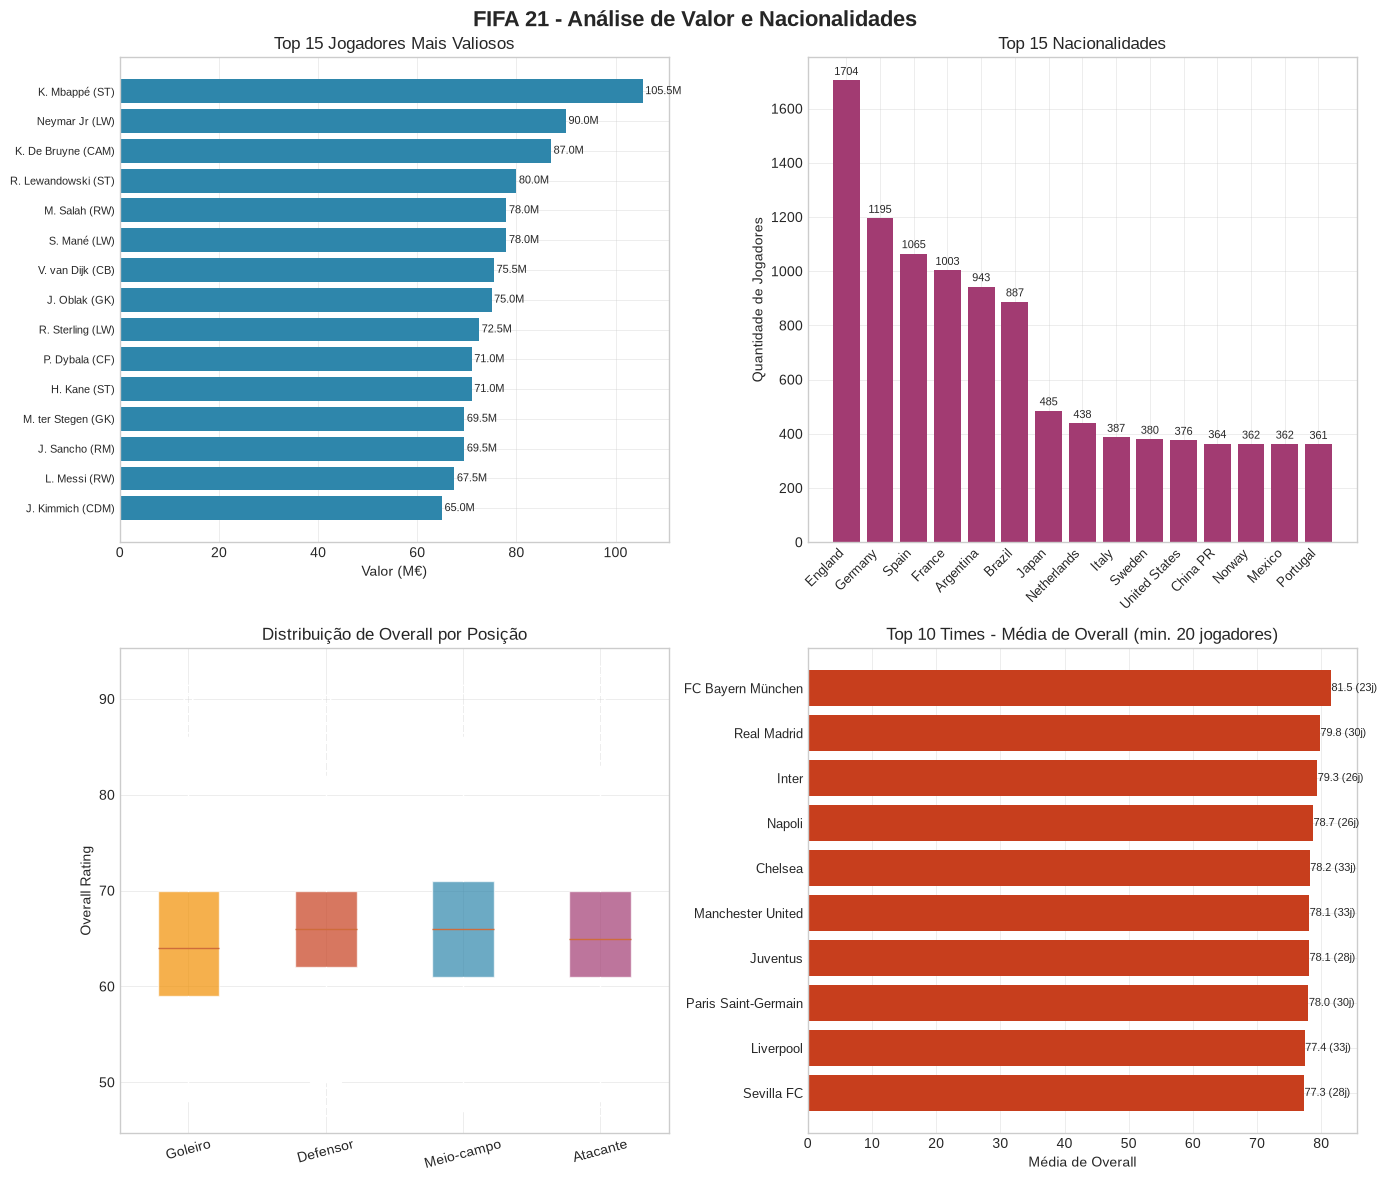

In [55]:

# Dashboard 2 corrigido: Análise de Valor e Nacionalidades
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('FIFA 21 - Análise de Valor e Nacionalidades', fontsize=16, fontweight='bold')

# 1. Top 15 jogadores mais valiosos
ax1 = axes[0, 0]
top_value = df.nlargest(15, 'Value_M')[['Name', 'Value_M', 'Main_Position']]
bars = ax1.barh(range(len(top_value)), top_value['Value_M'].values, color='#2E86AB')
ax1.set_yticks(range(len(top_value)))
ax1.set_yticklabels([f"{n} ({p})" for n, p in zip(top_value['Name'].values, top_value['Main_Position'].values)], fontsize=8)
ax1.set_xlabel('Valor (M€)')
ax1.set_title('Top 15 Jogadores Mais Valiosos')
ax1.invert_yaxis()
for i, v in enumerate(top_value['Value_M'].values):
    ax1.text(v + 0.5, i, f'{v:.1f}M', va='center', fontsize=8)

# 2. Top 15 nacionalidades com mais jogadores
ax2 = axes[0, 1]
top_nations = df['Nationality'].value_counts().head(15)
bars = ax2.bar(range(len(top_nations)), top_nations.values, color='#A23B72')
ax2.set_xticks(range(len(top_nations)))
ax2.set_xticklabels(top_nations.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Quantidade de Jogadores')
ax2.set_title('Top 15 Nacionalidades')
for i, v in enumerate(top_nations.values):
    ax2.text(i, v + 20, str(v), ha='center', fontsize=8)

# 3. Boxplot de Overall por categoria de posição - CORRIGIDO
ax3 = axes[1, 0]
pos_categories = ['Goleiro', 'Defensor', 'Meio-campo', 'Atacante']
data_to_plot = [df[df['Position_Category'] == cat]['OVA'].values for cat in pos_categories]
bp = ax3.boxplot(data_to_plot, patch_artist=True)
ax3.set_xticklabels(pos_categories)
colors = ['#F18F01', '#C73E1D', '#2E86AB', '#A23B72']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Overall Rating')
ax3.set_title('Distribuição de Overall por Posição')
ax3.tick_params(axis='x', rotation=15)

# 4. Top 10 times com maior média de Overall
ax4 = axes[1, 1]
team_avg = df.groupby('Team').agg({'OVA': 'mean', 'Name': 'count'}).reset_index()
team_avg = team_avg[team_avg['Name'] >= 20]
team_avg = team_avg.nlargest(10, 'OVA')
bars = ax4.barh(range(len(team_avg)), team_avg['OVA'].values, color='#C73E1D')
ax4.set_yticks(range(len(team_avg)))
ax4.set_yticklabels(team_avg['Team'].values, fontsize=9)
ax4.set_xlabel('Média de Overall')
ax4.set_title('Top 10 Times - Média de Overall (min. 20 jogadores)')
ax4.invert_yaxis()
for i, (v, c) in enumerate(zip(team_avg['OVA'].values, team_avg['Name'].values)):
    ax4.text(v + 0.1, i, f'{v:.1f} ({c}j)', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/mnt/agents/output/fifa21_dashboard2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard 2 corrigido e salvo!")
